# Rotations and Translations using the Spatial Math Toolbox


## 1. Setup and Installation


The following code installs and imports the packages needed for this notebook.

* `spatialmath-python` provides functions like `rotx`, `roty`, `rotz` and the `SE3` class for representing **rotations** and **rigid-body transformations**.
* `roboticstoolbox-python` builds on top of `spatialmath` for robotics-specific tools.
* `plotvol3` and `tranimate` (from `spatialmath.base`) are used to create **3D animations** of frames as they rotate or translate.

In [35]:
try:
    import google.colab
    print('Running on CoLab')
    COLAB = True
    !pip install spatialmath-python
except ModuleNotFoundError:
    COLAB = False

from IPython.display import HTML
import matplotlib.pyplot as plt
%matplotlib inline

# ------ standard imports ------ #
import numpy as np
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)

from spatialmath import *
from spatialmath.base import *

## 2. Elementary Rotation Matrices (about x,y,z-axis)


This example demonstrates the three **elementary rotation matrices**, each representing a rotation about a single coordinate axis.

* `rotx(theta)` rotates a frame by `theta` radians about the **x-axis**.
* `roty(theta)` rotates a frame by `theta` radians about the **y-axis**.
* `rotz(theta)` rotates a frame by `theta` radians about the **z-axis**.

Each rotation matrix `R` is animated using `tranimate`, which shows the coordinate frame smoothly rotating from its starting orientation to the final orientation defined by `R`.


In [11]:
R = rotx(np.pi/2)
plotvol3(new=True)
HTML(tranimate(R, movie=True,
    dims=[-1.5, 1.5, -1.5, 1.5, -1.5, 1.5]))


In [12]:
R = roty(np.pi/2)
plotvol3(new=True)
HTML(tranimate(R, movie=True,
    dims=[-1.5, 1.5, -1.5, 1.5, -1.5, 1.5]))


In [13]:
R = rotz(np.pi/2)
plotvol3(new=True)
HTML(tranimate(R, movie=True,
    dims=[-1.5, 1.5, -1.5, 1.5, -1.5, 1.5]))


## 3. 3D Rotation Matrix Visualization


The code demonstrates how to visualize a static coordinate frame using `trplot`, rather than animating it.

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

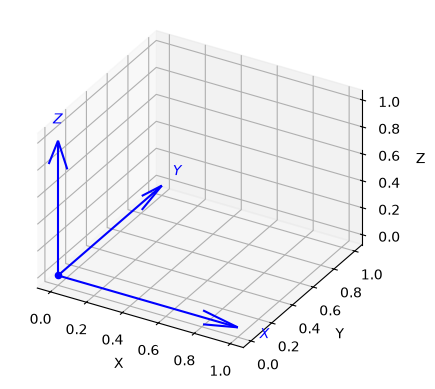

In [ ]:
# An identity matrix (np.eye(3)) represents a frame with no rotation, aligned with the world axes.
R = np.eye(3)
trplot(R)

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

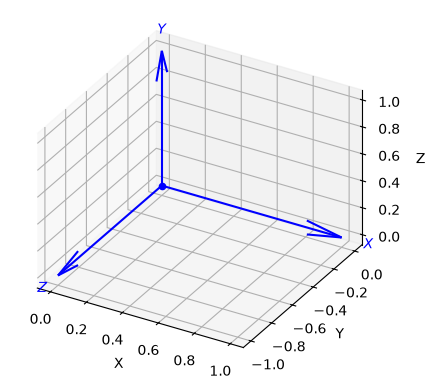

In [ ]:
# rotx(np.pi/2) shows a frame rotated 90 degrees about the x-axis
R = rotx(np.pi/2)
trplot(R)

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

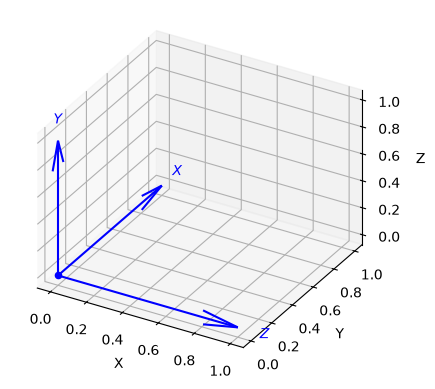

In [41]:
# Combining rotations with the @ operator (matrix multiplication), such as rotx(np.pi/2) @ roty(np.pi/2), applies successive rotations to build a more complex orientation.
R = rotx(np.pi/2) @ roty(np.pi/2)
trplot(R)

## 4. Pure Rotation Matrix (Animated)


This example shows how a rotation can be built up **gradually**, one small increment at a time, rather than jumping straight to the final orientation.

* `np.linspace(0, theta, 40)` generates 40 evenly spaced angles between 0 and the target angle `theta`.
* For each intermediate angle, `rotz(z)` computes the corresponding rotation matrix, and the result is stored in the `frames` list.
* `tranimate` then animates the frame smoothly rotating through all of these intermediate steps about the z-axis.

In [ ]:
theta = np.pi/2   # 90 degrees
frames = []
# Gradual rotation about Z
for z in np.linspace(0, theta, 40):
    frames.append(rotz(z))
plotvol3(new=True)
HTML(tranimate(frames, movie=True),)

## 5. Pure Translation Matrix (Animated)


This example demonstrates a **pure translation**, where a frame moves along an axis without changing orientation.

* The `SE3` class (imported from `spatialmath`) represents a full **rigid-body transformation** (rotation and translation together), and is used in the next section.
* `np.linspace(0, d, 50)` generates 50 evenly spaced positions between 0 and the target distance `d`.
* The `SE3` class (imported from `spatialmath`) represents a full **rigid-body transformation** (rotation and translation together), and is used in the next section.
* `SE3.Tx(x)` creates a transformation that translates the frame by `x` units along the **x-axis**.
* `tranimate` animates the frame gradually sliding along the x-axis through each of these intermediate positions.


In [ ]:
from spatialmath import SE3

d = 1.0   # move 1 units
frames = []
# Gradual translation along X
for x in np.linspace(0, d, 50):
    frames.append(SE3.Tx(x))
plotvol3(new=True)
HTML(tranimate(frames, movie=True),)

## 6. X-Y-Z Fixed Angle Rotation


The code demonstrates **fixed-angle rotations**, where each rotation is performed about a **fixed (world) axis**, rather than a moving local axis.

* `gamma`, `beta`, and `alpha` are the rotation angles about the fixed X, Y, and Z axes respectively.
* Because the axes are fixed, each new rotation matrix **pre-multiplies** the previous result: `R2 = roty(beta) @ R1`, then `R_fixed = rotz(alpha) @ R2`.
* `trplot` is used to visualize each intermediate frame (`R0`, `R1`, `R2`) as well as the final fixed-angle rotation `R_fixed`, so the effect of each step can be seen individually.


In [24]:
gamma = np.pi/4   # X rotation
beta  = np.pi/6   # Y rotation
alpha = np.pi/3   # Z rotation
# Identity
R0 = np.eye(3)
# Rotate about fixed X
R1 = rotx(gamma)
# Rotate about fixed Y (pre-multiply)
R2 = roty(beta) @ R1
# Rotate about fixed Z (pre-multiply)
R_fixed = rotz(alpha) @ R2

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

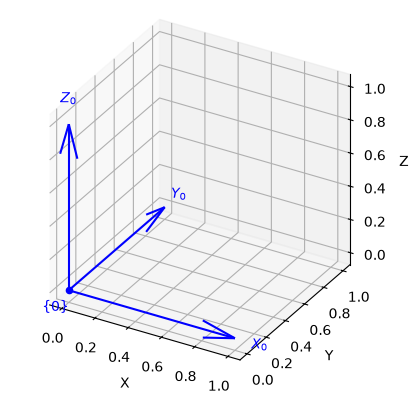

In [ ]:
plotvol3(new=True)
trplot(R0, frame='0')

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

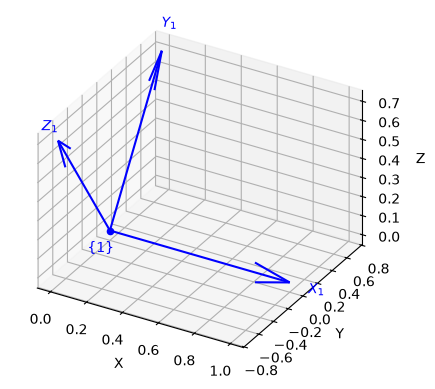

In [26]:
trplot(R1, frame='1')

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

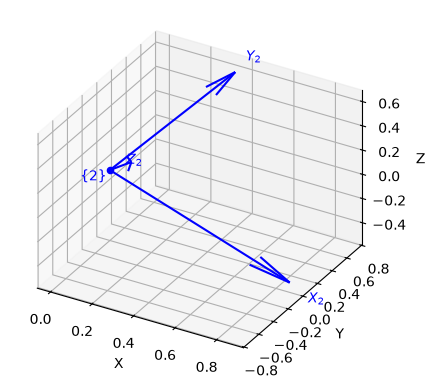

In [27]:
trplot(R2, frame='2')

Final Fixed Rotation Matrix:
[[   0.433  -0.4356   0.7891]
 [    0.75   0.6597 -0.04737]
 [    -0.5   0.6124   0.6124]]


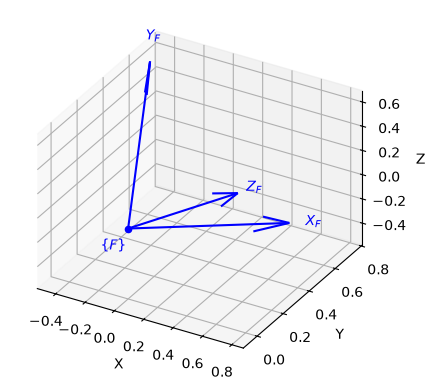

In [28]:
trplot(R_fixed, frame='F')
print("Final Fixed Rotation Matrix:")
print(R_fixed)

## 7. Z-Y-X Euler Angle Rotation


This example demonstrates **Euler-angle rotations**, where each rotation is performed about a **local (body-fixed) axis** that moves along with the frame as it rotates.

* `alpha`, `beta`, and `gamma` are the rotation angles about the local Z, Y, and X axes respectively.
* Because the axes are local, each new rotation matrix **post-multiplies** the previous result: `R2 = R1 @ roty(beta)`, then `R_euler = R2 @ rotx(gamma)`.
* As before, `trplot` is used to visualize each intermediate frame (`R0`, `R1`, `R2`) as well as the final Euler rotation `R_euler`.


In [30]:
alpha = np.pi/3   # Z rotation
beta  = np.pi/6   # Y rotation
gamma = np.pi/4   # X rotation
# Identity
R0 = np.eye(3)
# Rotate about local X
R1 = rotz(alpha)
# Rotate about local Y (post-multiply)
R2 = R1 @ roty(beta)
# Rotate about local Z (post-multiply)
R_euler = R2 @ rotx(gamma)

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

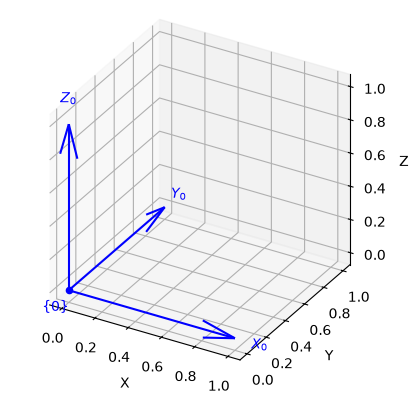

In [31]:
plotvol3(new=True)
trplot(R0, frame='0')

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

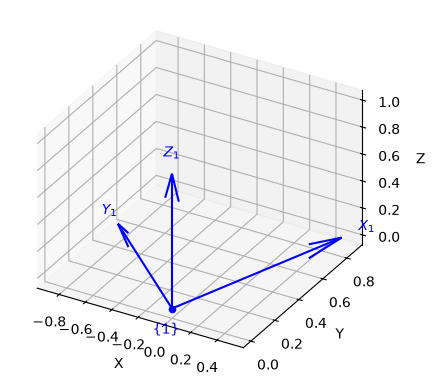

In [32]:
trplot(R1, frame='1')

<Axes3D: xlabel='X', ylabel='Y', zlabel='Z'>

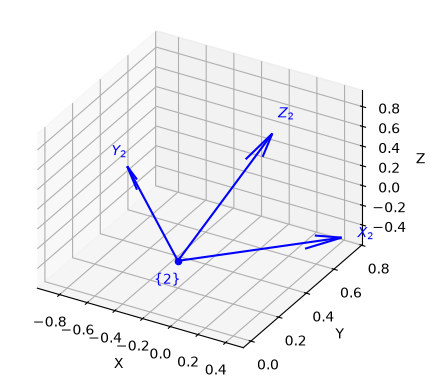

In [33]:
trplot(R2, frame='2')

Final Euler Rotation Matrix:
[[   0.433  -0.4356   0.7891]
 [    0.75   0.6597 -0.04737]
 [    -0.5   0.6124   0.6124]]


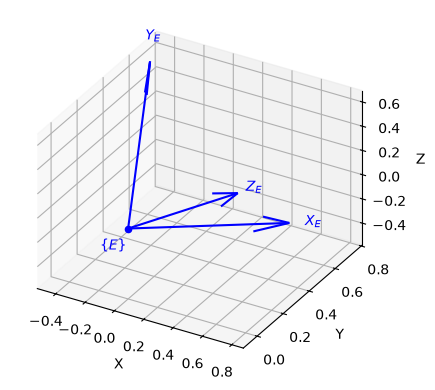

In [34]:
trplot(R_euler, frame='E')
print("Final Euler Rotation Matrix:")
print(R_euler)